# Student Focus Monitor — Facial State Classifier\n\nTrains a 4-class model that classifies a student's webcam frame into one of the states used by the Student Focus Monitor's gamification engine:\n\n- **Focused** — studying well\n- **Fatigue** — tired (blink rate up, yawning)\n- **Anxiety** — worried (eyes darting, brow furrowed, fidgeting)\n- **Boredom** — bored (gaze wandering, head turning, slumped posture)\n\n**Data sources**\n- `Focused` / `Fatigue` / `Anxiety` — the `face_detection` dataset (pre-cropped 224x224 faces, already split `train`/`valid`/`test`).\n- `Boredom` — the `DAiSEE` dataset only. DAiSEE has no folder of boredom images; instead it labels 10-second video clips with a crowd-annotated Boredom score (0-3). We pull a frame from every clip scored >= 2 and crop it to the face the same way as the other three classes, so the model can't just learn \"wide background = bored\" instead of an actual facial cue.\n\n**Modeling approach**\n1. Build the unified 4-class image dataset (`train`/`val`/`test`).\n2. Extract interpretable per-frame features (eye aspect ratio, mouth aspect ratio, brow position, gaze offset, head pose, 52 ARKit blendshapes) with MediaPipe's Face Landmarker — the same features the real-time system computes once a second.\n3. Train three classical classifiers on those features — Random Forest, XGBoost, SVM — and compare them.\n4. Train a MobileNetV2 CNN (two-stage transfer learning) directly on the cropped face images.\n5. Evaluate all four models on the same held-out test split and keep the most accurate one.

**Round 3 (confusion-matrix follow-up).** The SVM test matrix showed Fatigue at 100% (domain shortcut: no DAiSEE Fatigue), Anxiety recall 41% (Frustration proxy overlapping Boredom), and 29.6% of Focused predicted as Boredom (single middle frame). This round: (1) sample 5 frames per 10s clip, (2) add a DAiSEE Fatigue weak label, (3) tighten Anxiety so bored clips stay Boredom, (4) cost-sensitive + hard-example mining on classical models, (5) report Focused vs Distracted accuracy, (6) optional live-webcam holdout folder. Live `inference.py` also applies per-class 0.70 bars and a 45s temporal gate *before* the next retrain.

In [1]:
%matplotlib inline
import json
import random
import time
import warnings
import zlib
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.spatial.transform import Rotation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow:", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0 | GPUs: []


In [2]:
NOTEBOOK_DIR = Path.cwd()
BACKEND_ROOT = NOTEBOOK_DIR.parents[1]
assert (BACKEND_ROOT / "datasets" / "focusmonitor").exists(), f"Unexpected working directory: {NOTEBOOK_DIR}"

SOURCE_ROOT = BACKEND_ROOT / "datasets" / "focusmonitor"
FACE_DETECTION_ROOT = SOURCE_ROOT / "face_detection"
DAISEE_ROOT = SOURCE_ROOT / "DAiSEE"
UNIFIED_ROOT = BACKEND_ROOT / "datasets" / "focus_dataset_unified"
MODEL_DIR = BACKEND_ROOT / "trained-models" / "focus"
LANDMARKER_MODEL_PATH = NOTEBOOK_DIR / "models" / "face_landmarker.task"
FEATURES_CACHE_PATH = NOTEBOOK_DIR / "cache" / "landmark_features.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

CLASSES = ["Focused", "Fatigue", "Anxiety", "Boredom"]
SPLITS = ["train", "val", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

import sys
sys.path.insert(0, str(BACKEND_ROOT))
sys.path.insert(0, str(NOTEBOOK_DIR))

from round3 import (
    attach_clip_temporal_features,
    binary_focused_distracted,
    clip_frame_indices,
    cost_sensitive_sample_weights,
    live_holdout_dir,
    upsample_hard_examples,
)
from app.services.focus.focus_config import BOREDOM_FP_COST, CLASS_CONF_THRESHOLDS, TEMPORAL_FEATURE_NAMES

print("Backend root:      ", BACKEND_ROOT)
print("Unified dataset ->  ", UNIFIED_ROOT)
print("Trained models ->   ", MODEL_DIR)
print("Round-3 cost weights:", BOREDOM_FP_COST)

Backend root:       c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend
Unified dataset ->   c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\datasets\focus_dataset_unified
Trained models ->    c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\trained-models\focus
Round-3 cost weights: {'Focused': 1.6, 'Fatigue': 1.0, 'Anxiety': 1.8, 'Boredom': 0.7}


## 1. Build the unified dataset

Copies `Focused`/`Fatigue`/`Anxiety` from `face_detection` as-is, then adds a `Boredom` class (plus supplements for `Focused` and `Anxiety`) sampled from DAiSEE. Re-running this notebook top-to-bottom always rebuilds `focus_dataset_unified/` from scratch, so the result stays reproducible.

> **Revision note (round 2).** The first version of this pipeline made Boredom the *only* class ever sourced from DAiSEE, and it turned out DAiSEE's frames have a distinctive visual signature (video compression, resolution, sensor noise) that differs from `face_detection`'s clean, curated images. A model trained on that split learns "this looks like a DAiSEE frame" as a shortcut for "Boredom" -- confirmed by testing on DAiSEE clips explicitly labeled *not* bored, which still predicted Boredom with near-100% confidence.
>
> Round 1 added `domain_jitter` (randomized compression/blur/noise on every image) and a DAiSEE-sourced Focused supplement (Engagement==3 & Boredom==0). That cut the false-positive rate on held-out not-bored DAiSEE clips from 100% to 48% -- real progress, but the section 7 breakdown showed *zero* of those clips were ever predicted Fatigue, and very few Anxiety: with only Focused and Boredom having any DAiSEE-domain (real-video) representation, the model still partly falls back to "is this real video" to decide between those two whenever the DAiSEE-domain signal dominates.
>
> Round 2 adds a third DAiSEE-sourced supplement: **Anxiety**, proxied by DAiSEE's own Frustration score (Frustration >= 2 -- brow tension/frustration is a reasonable proxy for anxious tension, the same logic the project's earlier FER-based pipeline used for angry/fear). Fatigue has no comparable DAiSEE label to proxy from (DAiSEE doesn't capture drowsiness/yawning), so it remains `face_detection`-only; `domain_jitter`'s ranges are widened instead to close as much of that residual gap as augmentation alone can.

### 1.1 Focused / Fatigue / Anxiety -- from `face_detection`

These images are already cropped tightly to the face and pre-split into `train`/`valid`/`test` (verified below: MediaPipe's landmark bounding box already fills ~100% of the frame). We copy them into the unified layout (renaming `valid` -> `val`), applying `domain_jitter` to each one.

In [3]:
import shutil

FACE_DETECTION_SPLIT_MAP = {"train": "train", "valid": "val", "test": "test"}
FACE_DETECTION_CLASSES = ["Focused", "Fatigue", "Anxiety"]


def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)


def domain_jitter(image_bgr, seed):
    """Randomized resolution-loss + JPEG recompression + noise, applied to
    every image regardless of source. Prevents the model from using each
    source dataset's distinct compression/quality signature as a shortcut
    for its label -- see the revision note above. Ranges widened in round 2
    (0.5->0.35 min scale, 35->25 min JPEG quality, wider noise) since round 1's
    milder jitter alone still left a detectable domain gap for classes with no
    DAiSEE-domain representation (see section 7)."""
    rng = random.Random(seed)
    img = image_bgr
    h, w = img.shape[:2]

    scale = rng.uniform(0.35, 1.0)
    small = cv2.resize(img, (max(1, int(w * scale)), max(1, int(h * scale))), interpolation=cv2.INTER_AREA)
    img = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

    if rng.random() < 0.6:
        k = rng.choice([3, 5, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)

    quality = rng.randint(25, 90)
    ok, enc = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, quality])
    if ok:
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    noise_sigma = rng.uniform(0, 8)
    if noise_sigma > 0:
        noise = np.random.default_rng(seed).normal(0, noise_sigma, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return img


def build_face_detection_classes():
    if UNIFIED_ROOT.exists():
        shutil.rmtree(UNIFIED_ROOT)

    counts = {}
    for src_split, dst_split in FACE_DETECTION_SPLIT_MAP.items():
        for cls in FACE_DETECTION_CLASSES:
            files = list_images(FACE_DETECTION_ROOT / src_split / cls)
            dst_dir = UNIFIED_ROOT / dst_split / cls
            dst_dir.mkdir(parents=True, exist_ok=True)
            for f in files:
                img = domain_jitter(cv2.imread(str(f)), seed=zlib.crc32(f.name.encode()))
                cv2.imwrite(str(dst_dir / f.name), img)
            counts[(dst_split, cls)] = len(files)
    return counts


face_counts = build_face_detection_classes()
for (split, cls), n in sorted(face_counts.items()):
    print(f"{split:>5} / {cls:<8}: {n}")

 test / Anxiety : 67
 test / Fatigue : 67
 test / Focused : 61
train / Anxiety : 493
train / Fatigue : 437
train / Focused : 436
  val / Anxiety : 137
  val / Fatigue : 123
  val / Focused : 130


### 1.2 Boredom, Focused, and Anxiety supplements -- from DAiSEE

DAiSEE labels each clip with Boredom, Engagement, Confusion and Frustration scores (0-3 each, crowd-annotated). Round 3 pulls four disjoint sets and **5 frames per clip** (not the middle frame only):

- **Boredom** -- score >= 2 *and* Engagement <= 2.
- **Focused supplement** -- Engagement == 3 *and* Boredom == 0.
- **Anxiety supplement** -- Frustration >= 2 *and* Boredom <= 1 *and* Engagement >= 1 (Frustration is still a proxy; bored clips stay Boredom so they no longer cause the 43/43 split).
- **Fatigue supplement** -- Engagement <= 1 *and* Boredom == 0 *and* Frustration <= 1 (weak drowsiness proxy; DAiSEE has no yawn label).

Saved files are `DAiSEE_{clip}_f{i}.jpg` so later cells can attach blink/gaze/pose/yawn stats across the clip.

All three are disjoint by construction (Boredom>=2 rules out Boredom==0; Frustration is independent of the other two masks, and in practice barely overlaps them). Adding Focused and Anxiety supplements means three of the four classes have real DAiSEE-domain (webcam video) representation, not just Boredom -- this is what section 7's regression check is checking has actually closed the gap.

For every selected clip we take 5 evenly spaced frames, detect the face with MediaPipe and crop it with a small 5% margin -- matched to how tightly `face_detection`'s own images are cropped -- then apply the same `domain_jitter` used for the other classes.

The number of frames pulled per split (for each of the three sets) is capped at the *average* image count of `face_detection`'s three classes in that split, so no DAiSEE-sourced set dominates. DAiSEE's own Train/Validation/Test folders are split by person, and we route them 1:1 onto train/val/test so a person's face never crosses a split boundary.

In [4]:
BOREDOM_THRESHOLD = 2
FOCUSED_ENGAGEMENT_THRESHOLD = 3
ANXIETY_FRUSTRATION_THRESHOLD = 2
FRAMES_PER_CLIP = 5
CROP_MARGIN = 0.05
CROP_SIZE = 224

DAISEE_SPLIT_MAP = {
    "Train": ("TrainLabels.csv", "train"),
    "Validation": ("ValidationLabels.csv", "val"),
    "Test": ("TestLabels.csv", "test"),
}

target_daisee_counts = {
    dst_split: round(np.mean([face_counts[(dst_split, cls)] for cls in FACE_DETECTION_CLASSES]))
    for dst_split in set(FACE_DETECTION_SPLIT_MAP.values())
}
print(
    "Target DAiSEE-sourced CLIP count per split "
    f"(each clip contributes up to {FRAMES_PER_CLIP} frames):",
    target_daisee_counts,
)


def _load_daisee_labels(labels_csv: Path):
    df = pd.read_csv(labels_csv)
    df.columns = df.columns.str.strip()
    df["ClipID"] = df["ClipID"].astype(str).str.strip()
    return df


def load_bored_clip_ids(labels_csv: Path):
    df = _load_daisee_labels(labels_csv)
    mask = (df["Boredom"] >= BOREDOM_THRESHOLD) & (df["Engagement"] <= 2)
    return sorted(df[mask]["ClipID"].tolist())


def load_focused_proxy_clip_ids(labels_csv: Path):
    df = _load_daisee_labels(labels_csv)
    mask = (df["Engagement"] >= FOCUSED_ENGAGEMENT_THRESHOLD) & (df["Boredom"] == 0)
    return sorted(df[mask]["ClipID"].tolist())


def load_anxiety_proxy_clip_ids(labels_csv: Path):
    """Frustration without boredom — keeps Calm Quest from inheriting bored faces."""
    df = _load_daisee_labels(labels_csv)
    mask = (
        (df["Frustration"] >= ANXIETY_FRUSTRATION_THRESHOLD)
        & (df["Boredom"] <= 1)
        & (df["Engagement"] >= 1)
    )
    return sorted(df[mask]["ClipID"].tolist())


def load_fatigue_proxy_clip_ids(labels_csv: Path):
    """Weak drowsiness proxy: checked-out but not bored or frustrated."""
    df = _load_daisee_labels(labels_csv)
    mask = (df["Engagement"] <= 1) & (df["Boredom"] == 0) & (df["Frustration"] <= 1)
    return sorted(df[mask]["ClipID"].tolist())


def evenly_spaced_sample(items, cap):
    n = len(items)
    if n <= cap:
        return list(items)
    step = n / cap
    idx = sorted({int(i * step) for i in range(cap)})
    return [items[i] for i in idx]


def index_clip_files(split_dir: Path):
    return {p.name: p for p in split_dir.rglob("*.avi")}


def crop_face(image_bgr, landmarker, margin=CROP_MARGIN, out_size=CROP_SIZE):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)
    if not result.face_landmarks:
        return None

    h, w = image_bgr.shape[:2]
    xs = [p.x * w for p in result.face_landmarks[0]]
    ys = [p.y * h for p in result.face_landmarks[0]]
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    bw, bh = x1 - x0, y1 - y0
    x0, x1 = x0 - bw * margin, x1 + bw * margin
    y0, y1 = y0 - bh * margin, y1 + bh * margin
    x0, y0 = max(int(x0), 0), max(int(y0), 0)
    x1, y1 = min(int(x1), w), min(int(y1), h)
    if x1 <= x0 or y1 <= y0:
        return None

    crop = image_bgr[y0:y1, x0:x1]
    return cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_AREA)

Target DAiSEE-sourced CLIP count per split (each clip contributes up to 5 frames): {'test': 65, 'train': 455, 'val': 130}


In [5]:
def build_daisee_class(landmarker, clip_loader_fn, dest_class: str, label: str):
    """Shared extraction: qualifying clips -> up to FRAMES_PER_CLIP evenly spaced
    frames -> crop + jitter -> UNIFIED_ROOT/<split>/<dest_class>/DAiSEE_{id}_f{i}.jpg
    """
    ids_by_split = {
        daisee_split: clip_loader_fn(DAISEE_ROOT / "Labels" / labels_file)
        for daisee_split, (labels_file, _) in DAISEE_SPLIT_MAP.items()
    }

    counts, skipped_no_face, skipped_no_video = {}, 0, 0
    for daisee_split, (labels_file, unified_split) in DAISEE_SPLIT_MAP.items():
        clip_ids = ids_by_split[daisee_split]
        target = target_daisee_counts[unified_split]
        selected = evenly_spaced_sample(clip_ids, target)
        clip_index = index_clip_files(DAISEE_ROOT / "DataSet" / daisee_split)

        dst_dir = UNIFIED_ROOT / unified_split / dest_class
        dst_dir.mkdir(parents=True, exist_ok=True)

        n_saved = 0
        for clip_id in selected:
            video_path = clip_index.get(clip_id)
            if video_path is None:
                skipped_no_video += 1
                continue

            cap = cv2.VideoCapture(str(video_path))
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            for fi, frame_idx in enumerate(clip_frame_indices(frame_count, FRAMES_PER_CLIP)):
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ok, frame = cap.read()
                if not ok:
                    skipped_no_video += 1
                    continue
                face = crop_face(frame, landmarker)
                if face is None:
                    skipped_no_face += 1
                    continue
                face = domain_jitter(face, seed=zlib.crc32(f"{clip_id}_{fi}".encode()))
                out_path = dst_dir / f"DAiSEE_{Path(clip_id).stem}_f{fi}.jpg"
                cv2.imwrite(str(out_path), face)
                n_saved += 1
            cap.release()

        counts[unified_split] = n_saved
        print(
            f"[{label}] {daisee_split:>10}: {len(clip_ids)} qualifying clips, "
            f"{len(selected)} sampled (target {target}), {n_saved} saved -> {unified_split}/{dest_class}"
        )

    print(f"[{label}] Skipped: {skipped_no_video} clip/video read failures, {skipped_no_face} with no face detected\n")
    return counts


_daisee_landmarker_options = vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(LANDMARKER_MODEL_PATH)),
    num_faces=1,
    running_mode=vision.RunningMode.IMAGE,
)
_daisee_landmarker = vision.FaceLandmarker.create_from_options(_daisee_landmarker_options)

boredom_counts = build_daisee_class(_daisee_landmarker, load_bored_clip_ids, "Boredom", "Boredom")
focused_supplement_counts = build_daisee_class(_daisee_landmarker, load_focused_proxy_clip_ids, "Focused", "Focused-supplement")
anxiety_supplement_counts = build_daisee_class(_daisee_landmarker, load_anxiety_proxy_clip_ids, "Anxiety", "Anxiety-supplement")
fatigue_supplement_counts = build_daisee_class(_daisee_landmarker, load_fatigue_proxy_clip_ids, "Fatigue", "Fatigue-supplement")

[Boredom]      Train: 999 qualifying clips, 455 sampled (target 455), 2229 saved -> train/Boredom
[Boredom] Validation: 523 qualifying clips, 130 sampled (target 130), 650 saved -> val/Boredom
[Boredom]       Test: 300 qualifying clips, 65 sampled (target 65), 320 saved -> test/Boredom
[Boredom] Skipped: 10 clip/video read failures, 1 with no face detected

[Focused-supplement]      Train: 1594 qualifying clips, 455 sampled (target 455), 1980 saved -> train/Focused
[Focused-supplement] Validation: 247 qualifying clips, 130 sampled (target 130), 650 saved -> val/Focused
[Focused-supplement]       Test: 508 qualifying clips, 65 sampled (target 65), 285 saved -> test/Focused
[Focused-supplement] Skipped: 67 clip/video read failures, 0 with no face detected

[Anxiety-supplement]      Train: 102 qualifying clips, 102 sampled (target 455), 479 saved -> train/Anxiety
[Anxiety-supplement] Validation: 27 qualifying clips, 27 sampled (target 130), 135 saved -> val/Anxiety
[Anxiety-supplement]   

### 1.3 Class balance

Train Fatigue used to sit at 365 vs Focused 784. After the DAiSEE Fatigue supplement, if train Fatigue is still under 85% of train Focused we duplicate Fatigue images with a fresh `domain_jitter` seed (oversample, not synthetic faces).

Fatigue oversampled: +1501 (now 2053, focused 2416)


,train,val,test,total
Focused,2416,780,346,3542
Fatigue,2053,202,97,2352
Anxiety,972,272,311,1555
Boredom,2229,650,320,3199


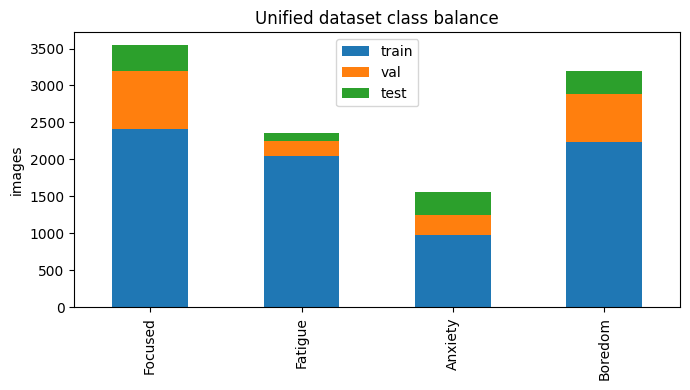

In [6]:
def count_images(folder: Path):
    return len(list_images(folder)) if folder.exists() else 0


def oversample_train_fatigue(target_ratio=0.85):
    """Duplicate train/Fatigue with a new jitter seed until it is closer to Focused."""
    src_dir = UNIFIED_ROOT / "train" / "Fatigue"
    focused_n = count_images(UNIFIED_ROOT / "train" / "Focused")
    fatigue_n = count_images(src_dir)
    target = int(focused_n * target_ratio)
    if fatigue_n >= target or fatigue_n == 0:
        print(f"Fatigue oversample skipped (have {fatigue_n}, target {target})")
        return 0
    files = list_images(src_dir)
    added = 0
    i = 0
    while fatigue_n + added < target:
        src = files[i % len(files)]
        img = cv2.imread(str(src))
        if img is None:
            i += 1
            continue
        jittered = domain_jitter(img, seed=zlib.crc32(f"oversample_{i}_{src.name}".encode()))
        out = src_dir / f"oversample_{i}_{src.name}"
        cv2.imwrite(str(out), jittered)
        added += 1
        i += 1
    print(f"Fatigue oversampled: +{added} (now {fatigue_n + added}, focused {focused_n})")
    return added


oversample_train_fatigue()

balance = pd.DataFrame(
    {split: [count_images(UNIFIED_ROOT / split / cls) for cls in CLASSES] for split in SPLITS},
    index=CLASSES,
)
balance["total"] = balance[SPLITS].sum(axis=1)
display(balance)

balance[SPLITS].plot(kind="bar", stacked=True, figsize=(7, 4), title="Unified dataset class balance")
plt.ylabel("images")
plt.tight_layout()
plt.savefig(MODEL_DIR / "class_balance.png")
plt.show()

## 2. Feature engineering (MediaPipe Face Landmarker)\n\nFor every image in the unified dataset, run MediaPipe's Face Landmarker (478 landmarks + 52 blendshapes + a head-pose transformation matrix) and derive:\n\n- **Eye tracking** — eye aspect ratio per eye (blink proxy) and iris offset within the eye socket per eye (gaze proxy).\n- **Face tracking** — mouth aspect ratio (yawn proxy), brow-to-eye distance per side (furrow/raise proxy), and all 52 ARKit blendshape scores (covers facial tension generally — jaw, cheeks, lip press, etc.).\n- **Head pose** — pitch/yaw/roll decomposed from the landmarker's facial transformation matrix.
- **Temporal (round 3)** — DAiSEE clips that saved 5 frames also get EAR std / blink rate, gaze (x,y) std, head-pose std, and MAR yawn counts across the clip. Still `face_detection` images get zeros. Live inference computes the same stats over a 45s webcam buffer.\n\nImages where no face is detected are dropped from this tabular feature set (they're still used later for the CNN, which learns directly from pixels). Results are cached to `cache/landmark_features.csv` — delete that file to force a recompute after changing the dataset.

In [8]:
# Landmark index sets (MediaPipe FaceMesh topology, 478 points incl. iris)
EYE_LEFT = [33, 160, 158, 133, 153, 144]     # corner, top1, top2, corner, bottom1, bottom2
EYE_RIGHT = [263, 387, 385, 362, 380, 373]
MOUTH_CORNERS = (61, 291)
MOUTH_VERTICAL = (13, 14)
BROW_LEFT, EYE_TOP_LEFT = 105, 159
BROW_RIGHT, EYE_TOP_RIGHT = 334, 386
IRIS_LEFT, IRIS_RIGHT = 468, 473


def _dist(a, b):
    return float(np.hypot(a.x - b.x, a.y - b.y))


def _ear(lm, idx):
    p1, p2, p3, p4, p5, p6 = (lm[i] for i in idx)
    return (_dist(p2, p6) + _dist(p3, p5)) / (2 * _dist(p1, p4) + 1e-6)


def _mar(lm):
    top, bottom = lm[MOUTH_VERTICAL[0]], lm[MOUTH_VERTICAL[1]]
    left, right = lm[MOUTH_CORNERS[0]], lm[MOUTH_CORNERS[1]]
    return _dist(top, bottom) / (_dist(left, right) + 1e-6)


def _iris_offset(lm, iris_idx, eye_idx):
    iris = lm[iris_idx]
    corner1, corner2 = lm[eye_idx[0]], lm[eye_idx[3]]
    top, bottom = lm[eye_idx[1]], lm[eye_idx[4]]
    eye_w = _dist(corner1, corner2) + 1e-6
    eye_h = _dist(top, bottom) + 1e-6
    cx, cy = (corner1.x + corner2.x) / 2, (top.y + bottom.y) / 2
    return (iris.x - cx) / eye_w, (iris.y - cy) / eye_h


def _head_pose(matrix):
    rotation = np.array(matrix)[:3, :3]
    return Rotation.from_matrix(rotation).as_euler("xyz", degrees=True)


def extract_features(landmarker, image_bgr):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)
    if not result.face_landmarks:
        return None
    lm = result.face_landmarks[0]

    ear_l, ear_r = _ear(lm, EYE_LEFT), _ear(lm, EYE_RIGHT)
    gaze_lx, gaze_ly = _iris_offset(lm, IRIS_LEFT, EYE_LEFT)
    gaze_rx, gaze_ry = _iris_offset(lm, IRIS_RIGHT, EYE_RIGHT)

    features = {
        "ear_left": ear_l,
        "ear_right": ear_r,
        "ear_avg": (ear_l + ear_r) / 2,
        "mar": _mar(lm),
        "brow_eye_dist_left": lm[EYE_TOP_LEFT].y - lm[BROW_LEFT].y,
        "brow_eye_dist_right": lm[EYE_TOP_RIGHT].y - lm[BROW_RIGHT].y,
        "gaze_x_left": gaze_lx,
        "gaze_y_left": gaze_ly,
        "gaze_x_right": gaze_rx,
        "gaze_y_right": gaze_ry,
    }

    if result.facial_transformation_matrixes:
        pitch, yaw, roll = _head_pose(result.facial_transformation_matrixes[0])
    else:
        pitch, yaw, roll = 0.0, 0.0, 0.0
    features.update({"head_pitch": pitch, "head_yaw": yaw, "head_roll": roll})

    if result.face_blendshapes:
        for bs in result.face_blendshapes[0]:
            features[f"bs_{bs.category_name}"] = bs.score

    return features

In [9]:
def build_feature_table():
    base_options = mp_python.BaseOptions(model_asset_path=str(LANDMARKER_MODEL_PATH))
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=True,
        output_facial_transformation_matrixes=True,
        num_faces=1,
        running_mode=vision.RunningMode.IMAGE,
    )
    landmarker = vision.FaceLandmarker.create_from_options(options)

    rows = []
    n_total, n_failed = 0, 0
    t0 = time.time()
    for split in SPLITS:
        for cls in CLASSES:
            files = list_images(UNIFIED_ROOT / split / cls)
            for f in files:
                n_total += 1
                image = cv2.imread(str(f))
                feats = extract_features(landmarker, image) if image is not None else None
                if feats is None:
                    n_failed += 1
                    continue
                feats.update({"split": split, "label": cls, "file": str(f)})
                rows.append(feats)
            print(f"{split}/{cls}: {len(files)} images processed", end="\r")

    print(f"\nDone in {time.time() - t0:.1f}s. {len(rows)}/{n_total} images yielded features ({n_failed} failed face detection).")
    return pd.DataFrame(rows)


if FEATURES_CACHE_PATH.exists():
    features_df = pd.read_csv(FEATURES_CACHE_PATH)
    print(f"Loaded cached features: {features_df.shape}")
else:
    features_df = build_feature_table()
    features_df.to_csv(FEATURES_CACHE_PATH, index=False)
    print(f"Cached features to {FEATURES_CACHE_PATH}: {features_df.shape}")

features_df.head()

Loaded cached features: (3108, 68)


,ear_left,ear_right,ear_avg,mar,brow_eye_dist_left,brow_eye_dist_right,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,...,bs_mouthSmileRight,bs_mouthStretchLeft,bs_mouthStretchRight,bs_mouthUpperUpLeft,bs_mouthUpperUpRight,bs_noseSneerLeft,bs_noseSneerRight,split,label,file
0,0.239603,0.246552,0.243078,0.033244,0.098207,0.118803,-0.042656,-0.085786,0.016595,-0.063060,...,0.040836,0.088050,0.007578,0.053737,0.146944,0.000023,4.612782e-07,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
1,0.204014,0.231152,0.217583,0.162890,0.114747,0.123641,-0.051961,-0.059286,0.017568,-0.066923,...,0.013911,0.003875,0.041873,0.286016,0.513872,0.000038,1.565512e-06,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
2,0.234586,0.268335,0.251461,0.031727,0.107110,0.112981,-0.073312,-0.066113,-0.009979,-0.079769,...,0.072010,0.053788,0.027513,0.037260,0.158246,0.000018,6.164178e-07,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
3,0.214392,0.250379,0.232386,0.164769,0.116944,0.113254,-0.038252,-0.046811,0.052458,-0.054842,...,0.187145,0.030444,0.185737,0.293849,0.633673,0.000026,1.639988e-06,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
4,0.192876,0.235373,0.214125,0.205337,0.117722,0.120313,-0.066526,-0.045408,0.024993,-0.053725,...,0.117783,0.026484,0.208807,0.358069,0.715183,0.000029,2.020573e-06,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...


## 3. Tabular preprocessing\n\nFeatures are scaled with a `StandardScaler` fit on the train split only, and split strictly along the same train/val/test folders used for the images — no re-shuffling, so results stay comparable with the CNN.

In [10]:
features_df = attach_clip_temporal_features(features_df)

FEATURE_COLUMNS = [c for c in features_df.columns if c not in {"split", "label", "file"}]

label_to_idx = {c: i for i, c in enumerate(CLASSES)}
features_df["label_idx"] = features_df["label"].map(label_to_idx)


def split_xy(split_name):
    sub = features_df[features_df["split"] == split_name]
    return sub[FEATURE_COLUMNS].values, sub["label_idx"].values


X_train_raw, y_train = split_xy("train")
X_val_raw, y_val = split_xy("val")
X_test_raw, y_test = split_xy("test")

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# Balanced weights, then extra cost so Focused/Anxiety → Boredom hurts more
# than missing a true Boredom (the 40% precision leak).
train_sample_weight = cost_sensitive_sample_weights(y_train)

print(f"feature count: {len(FEATURE_COLUMNS)}")
print(f"train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}")
print("train class counts:", {CLASSES[i]: int((y_train == i).sum()) for i in range(len(CLASSES))})

feature count: 75
train: (2117, 75)  val: (650, 75)  test: (341, 75)
train class counts: {'Focused': 784, 'Fatigue': 365, 'Anxiety': 529, 'Boredom': 439}


## 4. Classical ML models: Random Forest, XGBoost, SVM\n\nEach gets a `RandomizedSearchCV` (3-fold CV, within the train split only) over a modest hyperparameter grid, then is scored on the held-out validation split.

In [11]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=1, class_weight="balanced"),
    rf_param_dist,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train, sample_weight=train_sample_weight)
rf_model = rf_search.best_estimator_
rf_val_acc = accuracy_score(y_val, rf_model.predict(X_val))
print("RF best params:", rf_search.best_params_)
print(f"RF val accuracy: {rf_val_acc:.4f}")

RF best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
RF val accuracy: 0.6538


In [12]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASSES),
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ),
    xgb_param_dist,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train, sample_weight=train_sample_weight)
xgb_model = xgb_search.best_estimator_
xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val))
print("XGBoost best params:", xgb_search.best_params_)
print(f"XGBoost val accuracy: {xgb_val_acc:.4f}")

xgb_hard_pred = xgb_model.predict(X_train)
X_xgb_hard, y_xgb_hard, n_xgb_hard = upsample_hard_examples(X_train, y_train, xgb_hard_pred)
if n_xgb_hard:
    xgb_model.fit(X_xgb_hard, y_xgb_hard, sample_weight=cost_sensitive_sample_weights(y_xgb_hard))
    xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val))
    print(f"XGBoost hard-example refit: {n_xgb_hard} leak rows ×3, val acc now {xgb_val_acc:.4f}")

XGBoost best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
XGBoost val accuracy: 0.6585
XGBoost hard-example refit: 6 leak rows ×3, val acc now 0.6538


In [13]:
svm_param_dist = {
    "C": [0.1, 1, 3, 10, 30, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "kernel": ["rbf"],
}
svm_search = RandomizedSearchCV(
    SVC(probability=True, random_state=RANDOM_SEED, class_weight="balanced"),
    svm_param_dist,
    n_iter=15,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
svm_search.fit(X_train, y_train, sample_weight=train_sample_weight)
svm_model = svm_search.best_estimator_
svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val))
print("SVM best params:", svm_search.best_params_)
print(f"SVM val accuracy: {svm_val_acc:.4f}")

# Confusion-matrix-aware retrain: upsample Focused/Anxiety rows the first SVM
# called Boredom, then refit with the same hyperparameters.
hard_pred = svm_model.predict(X_train)
X_hard, y_hard, n_hard = upsample_hard_examples(X_train, y_train, hard_pred)
if n_hard:
    hard_weights = cost_sensitive_sample_weights(y_hard)
    svm_model.fit(X_hard, y_hard, sample_weight=hard_weights)
    svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val))
    print(f"SVM hard-example refit: {n_hard} leak rows ×3, val acc now {svm_val_acc:.4f}")
else:
    print("SVM hard-example refit skipped (no Focused/Anxiety → Boredom on train)")

SVM best params: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}
SVM val accuracy: 0.6123
SVM hard-example refit: 126 leak rows ×3, val acc now 0.5631


In [14]:
classical_models = {"Random Forest": rf_model, "XGBoost": xgb_model, "SVM": svm_model}

classical_results = pd.DataFrame(
    {"model": list(classical_models.keys()), "val_accuracy": [rf_val_acc, xgb_val_acc, svm_val_acc]}
).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
display(classical_results)

best_classical_name = classical_results.iloc[0]["model"]
best_classical_model = classical_models[best_classical_name]
print(f"Best classical model on validation set: {best_classical_name} ({classical_results.iloc[0]['val_accuracy']:.4f})")

,model,val_accuracy
0,Random Forest,0.653846
1,XGBoost,0.653846
2,SVM,0.563077


Best classical model on validation set: Random Forest (0.6538)


## 5. CNN: MobileNetV2 transfer learning\n\nTwo-stage transfer learning on top of ImageNet-pretrained MobileNetV2:\n1. **Stage 1** — backbone frozen, train only the classification head.\n2. **Stage 2** — unfreeze the last 20 backbone layers and fine-tune at a much lower learning rate.\n\nBoth stages use class weights (from the train split's label distribution) and early stopping on validation loss.

In [15]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


def load_split_ds(split_name, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        UNIFIED_ROOT / split_name,
        labels="inferred",
        label_mode="int",
        class_names=CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=RANDOM_SEED,
    )


train_ds_raw = load_split_ds("train", shuffle=True)
val_ds_raw = load_split_ds("val", shuffle=False)
test_ds_raw = load_split_ds("test", shuffle=False)

cnn_class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=np.concatenate([y.numpy() for _, y in train_ds_raw]),
)
cnn_class_weights = dict(zip(range(len(CLASSES)), cnn_class_weights_arr))
print("CNN class weights:", {CLASSES[i]: round(w, 3) for i, w in cnn_class_weights.items()})

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().prefetch(AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(AUTOTUNE)

Found 7670 files belonging to 4 classes.
Found 1904 files belonging to 4 classes.
Found 1074 files belonging to 4 classes.
CNN class weights: {'Focused': np.float64(0.794), 'Fatigue': np.float64(0.934), 'Anxiety': np.float64(1.973), 'Boredom': np.float64(0.86)}


In [16]:
STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 6
STAGE1_LR = 1e-3
STAGE2_LR = 1e-5
FINE_TUNE_LAYERS = 20
EARLY_STOPPING_PATIENCE = 3


def build_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomBrightness(0.15),
            tf.keras.layers.RandomZoom(0.15),
        ],
        name="augmentation",
    )


def build_cnn_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = build_augmentation()(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(len(CLASSES), activation="softmax")(x)
    return tf.keras.Model(inputs, outputs), base_model


cnn_model, cnn_base_model = build_cnn_model()
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(STAGE1_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("=== Stage 1: training classification head (backbone frozen) ===")
stage1_es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True
)
history1 = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=STAGE1_EPOCHS, class_weight=cnn_class_weights, callbacks=[stage1_es]
)

cnn_base_model.trainable = True
for layer in cnn_base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(STAGE2_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print(f"\n=== Stage 2: fine-tuning last {FINE_TUNE_LAYERS} backbone layers ===")
stage2_es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True
)
history2 = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=STAGE2_EPOCHS, class_weight=cnn_class_weights, callbacks=[stage2_es]
)

=== Stage 1: training classification head (backbone frozen) ===
Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 202s 822ms/step - accuracy: 0.5606 - loss: 1.0071 - val_accuracy: 0.4800 - val_loss: 1.1339
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 197s 819ms/step - accuracy: 0.6360 - loss: 0.8593 - val_accuracy: 0.5305 - val_loss: 1.1249
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 196s 818ms/step - accuracy: 0.6405 - loss: 0.8325 - val_accuracy: 0.5163 - val_loss: 1.1582
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 186s 774ms/step - accuracy: 0.6597 - loss: 0.7995 - val_accuracy: 0.5373 - val_loss: 1.0701
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 183s 764ms/step - accuracy: 0.6675 - loss: 0.7783 - val_accuracy: 0.5425 - val_loss: 1.1122
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 183s 762ms/step - accuracy: 0.6768 - loss: 0.7629 - val_accuracy: 0.5341 - val_loss: 1.1120
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 188s 784ms/step - accuracy: 0.6761 - loss: 0.7584 - val_accuracy: 0.5378 - val_loss: 1.0972

=== Stage 2

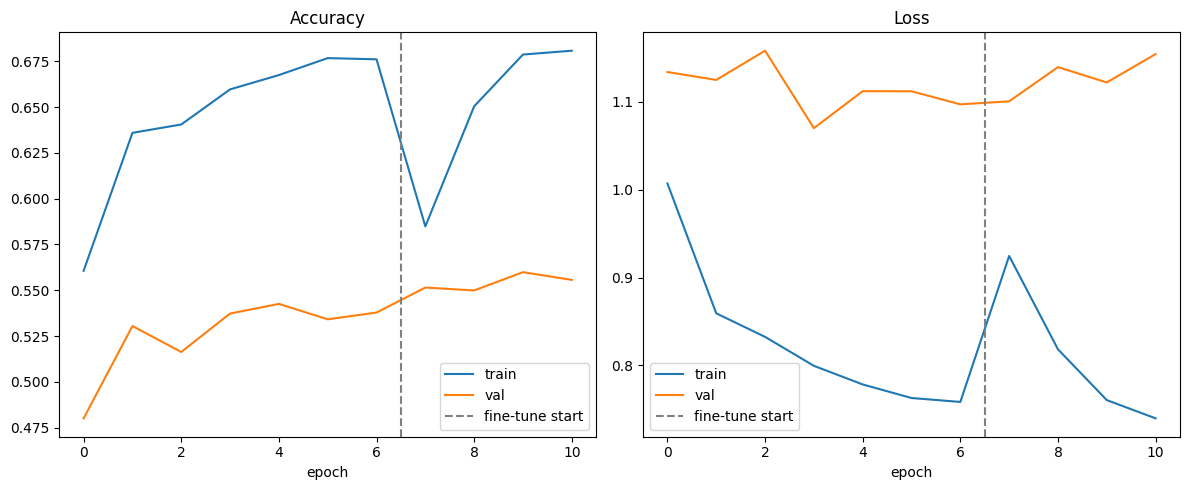

In [18]:
def plot_training_curves(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]
    boundary = len(h1.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(acc, label="train")
    axes[0].plot(val_acc, label="val")
    axes[0].axvline(boundary - 0.5, color="gray", linestyle="--", label="fine-tune start")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(loss, label="train")
    axes[1].plot(val_loss, label="val")
    axes[1].axvline(boundary - 0.5, color="gray", linestyle="--", label="fine-tune start")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(MODEL_DIR / "training_curves.png")
    plt.show()


plot_training_curves(history1, history2)

## 6. Final comparison and model selection\n\nAll four models — Random Forest, XGBoost, SVM, and the MobileNetV2 CNN — are evaluated on the same held-out test split. The most accurate one is kept as the final model for the Student Focus Monitor.

34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 543ms/step


,model,test_accuracy,test_macro_f1
0,XGBoost,0.648094,0.595988
1,Random Forest,0.615836,0.604703
2,SVM,0.609971,0.593370
3,MobileNetV2 CNN,0.482309,0.514254


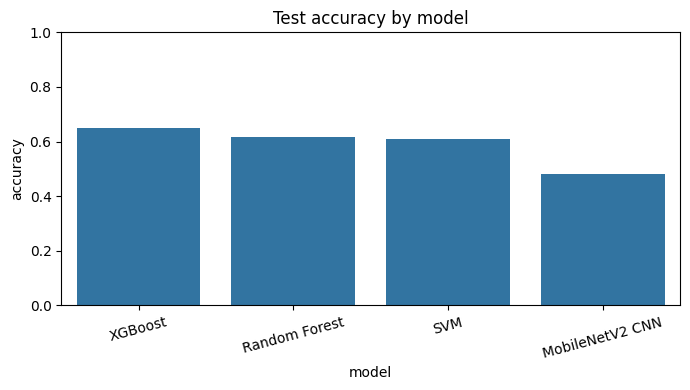


Best model on the held-out test set: XGBoost (accuracy=0.6481)


In [19]:
def eval_on_test(model, kind):
    if kind == "cnn":
        y_true = np.concatenate([y.numpy() for _, y in test_ds])
        y_pred = np.argmax(model.predict(test_ds), axis=1)
    else:
        y_true = y_test
        y_pred = model.predict(X_test)
    return y_true, y_pred, accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro")


all_models = {
    "Random Forest": ("classical", rf_model),
    "XGBoost": ("classical", xgb_model),
    "SVM": ("classical", svm_model),
    "MobileNetV2 CNN": ("cnn", cnn_model),
}

comparison_rows = []
predictions = {}
for name, (kind, model) in all_models.items():
    y_true, y_pred, acc, f1 = eval_on_test(model, kind)
    comparison_rows.append({"model": name, "test_accuracy": acc, "test_macro_f1": f1})
    predictions[name] = (y_true, y_pred)

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
display(comparison_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x="model", y="test_accuracy")
plt.ylim(0, 1)
plt.title("Test accuracy by model")
plt.ylabel("accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(MODEL_DIR / "model_comparison.png")
plt.show()

best_model_name = comparison_df.iloc[0]["model"]
print(f"\nBest model on the held-out test set: {best_model_name} (accuracy={comparison_df.iloc[0]['test_accuracy']:.4f})")

=== Test-set classification report: XGBoost ===
              precision    recall  f1-score   support

     Focused      0.554     0.896     0.684       115
     Fatigue      1.000     0.982     0.991        56
     Anxiety      0.648     0.557     0.599       106
     Boredom      0.444     0.062     0.110        64

    accuracy                          0.648       341
   macro avg      0.662     0.624     0.596       341
weighted avg      0.636     0.648     0.600       341



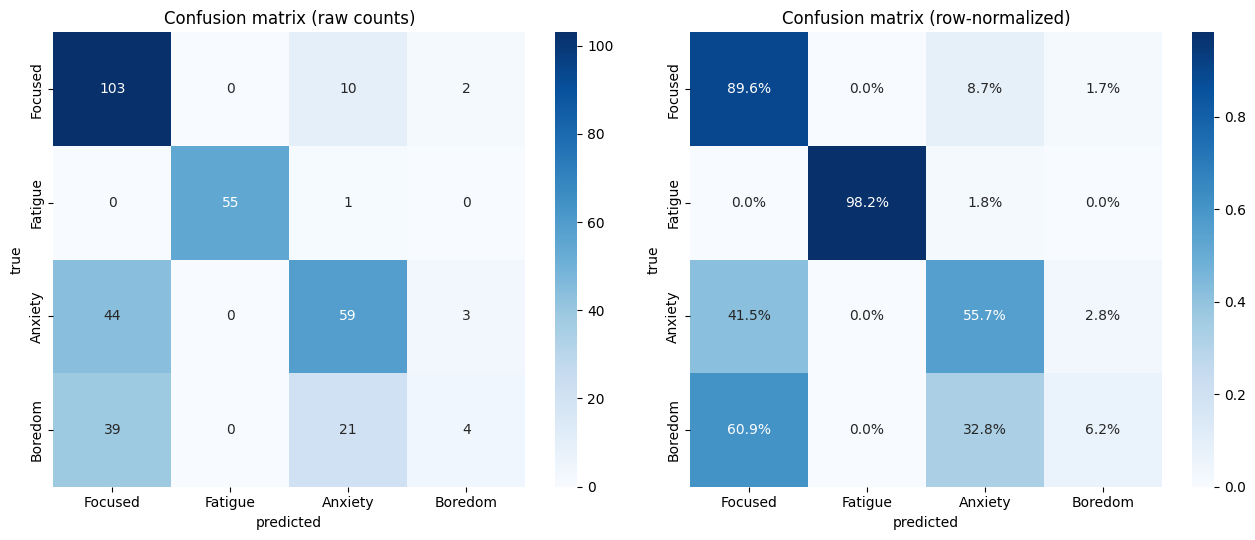


=== Focused vs Distracted (honest demo number) ===
binary accuracy: 0.721
confusion [rows=true Focused/Distracted, cols=pred]: [[103, 12], [83, 143]]
Distracted recall: 0.633   precision: 0.923


In [20]:
y_true_best, y_pred_best = predictions[best_model_name]

report_text = classification_report(y_true_best, y_pred_best, target_names=CLASSES, digits=3)
print(f"=== Test-set classification report: {best_model_name} ===")
print(report_text)

cm = confusion_matrix(y_true_best, y_pred_best, labels=np.arange(len(CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Confusion matrix (raw counts)")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")

sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title("Confusion matrix (row-normalized)")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("true")

fig.tight_layout()
fig.savefig(MODEL_DIR / "confusion_matrix.png")
plt.show()

report_dict = classification_report(y_true_best, y_pred_best, target_names=CLASSES, digits=3, output_dict=True)
with open(MODEL_DIR / "test_classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)
with open(MODEL_DIR / "test_classification_report.txt", "w") as f:
    f.write(report_text)

binary = binary_focused_distracted(y_true_best, y_pred_best)
print("\n=== Focused vs Distracted (honest demo number) ===")
print(f"binary accuracy: {binary['accuracy']:.3f}")
print("confusion [rows=true Focused/Distracted, cols=pred]:", binary["confusion"])
print(
    "Distracted recall:",
    f"{binary['report']['Distracted']['recall']:.3f}",
    "  precision:",
    f"{binary['report']['Distracted']['precision']:.3f}",
)
with open(MODEL_DIR / "binary_focused_distracted.json", "w") as f:
    json.dump(binary, f, indent=2)

In [21]:
results_summary = {
    "classes": CLASSES,
    "comparison": comparison_df.to_dict(orient="records"),
    "best_model": best_model_name,
    "boredom_threshold": BOREDOM_THRESHOLD,
    "feature_columns": FEATURE_COLUMNS,
    "binary_focused_distracted_accuracy": binary["accuracy"],
    "inference": {
        "class_conf_thresholds": CLASS_CONF_THRESHOLDS,
        "temporal_window_seconds": 45,
        "majority_vote_seconds": 20,
        "intervention_conf_thresholds": {"Fatigue": 0.70, "Anxiety": 0.75, "Boredom": 0.80},
    },
    "round3": {
        "frames_per_clip": FRAMES_PER_CLIP,
        "boredom_fp_cost": BOREDOM_FP_COST,
        "temporal_features": TEMPORAL_FEATURE_NAMES,
    },
}

if best_model_name == "MobileNetV2 CNN":
    cnn_model.save(MODEL_DIR / "focus_mobilenetv2.keras")
    print(f"Saved CNN model to {MODEL_DIR / 'focus_mobilenetv2.keras'}")
else:
    best_model_obj = all_models[best_model_name][1]
    joblib.dump(best_model_obj, MODEL_DIR / "focus_classical_model.joblib")
    joblib.dump(scaler, MODEL_DIR / "feature_scaler.joblib")
    print(f"Saved {best_model_name} model to {MODEL_DIR / 'focus_classical_model.joblib'}")

with open(MODEL_DIR / "results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)
print(f"Saved results summary to {MODEL_DIR / 'results_summary.json'}")

Saved XGBoost model to c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\trained-models\focus\focus_classical_model.joblib
Saved results summary to c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\trained-models\focus\results_summary.json


## 7. Cross-domain regression check

This is the test that originally caught the DAiSEE-domain shortcut: run the winning model on DAiSEE clips it never saw during training (excluded by clip id, not just a random sample), split into clips truly labeled Boredom>=2 and clips truly labeled Boredom==0, and check that the *not-bored* clips are no longer predicted as Boredom almost unconditionally. This goes through the exact same crop -> feature/pixel -> predict path the backend's `inference.py` uses, not the cached training features, so it's a genuine end-to-end check.

In [22]:
N_HELDOUT_PER_GROUP = 25

from app.services.focus.temporal import compute_temporal_stats

used_daisee_stems = {
    # Round 3 names are DAiSEE_{clip}_f{i}; older runs used DAiSEE_{clip}.
    p.stem.replace("DAiSEE_", "", 1).rsplit("_f", 1)[0]
    for split in SPLITS
    for cls in CLASSES
    for p in list_images(UNIFIED_ROOT / split / cls)
    if p.name.startswith("DAiSEE_")
}
print(f"{len(used_daisee_stems)} DAiSEE clip stems already used in the unified dataset (excluded below)")

# A fresh landmarker with blendshapes + transformation matrix enabled --
# `_daisee_landmarker` from section 1.2 was only ever used for crop bounding
# boxes and was built without those outputs, so it can't be reused here.
_regression_landmarker = vision.FaceLandmarker.create_from_options(
    vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(LANDMARKER_MODEL_PATH)),
        output_face_blendshapes=True,
        output_facial_transformation_matrixes=True,
        num_faces=1,
        running_mode=vision.RunningMode.IMAGE,
    )
)


def predict_single_frame(frame_bgr, landmarker):
    """Mirrors backend/app/services/focus/inference.py's predict_from_frame:
    crop -> features (classical) or pixels (CNN) -> predict. Used here so
    this regression check exercises the real serving path, not the cached
    training features."""
    face = crop_face(frame_bgr, landmarker)
    if face is None:
        return None
    if best_model_name == "MobileNetV2 CNN":
        img = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img.astype(np.float32))
        probs = cnn_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    else:
        feats = extract_features(landmarker, face)
        if feats is None:
            return None
        # Round-3 models include clip-window columns (ear_std, gaze std, …).
        # A single held-out frame has no window, so fill those the same way
        # inference.py does: compute_temporal_stats on a 1-frame list (stds=0)
        # and .get(..., 0.0) so a missing name never KeyErrors.
        feats = {**feats, **compute_temporal_stats([feats])}
        vec = scaler.transform(np.array([[feats.get(c, 0.0) for c in FEATURE_COLUMNS]]))
        probs = all_models[best_model_name][1].predict_proba(vec)[0]
    return CLASSES[int(np.argmax(probs))]


def heldout_clip_frames(labels_csv, mask_fn, n, exclude_stems, video_dir):
    df = _load_daisee_labels(labels_csv)
    candidates = df[mask_fn(df)]["ClipID"].tolist()
    candidates = [c for c in candidates if Path(c).stem not in exclude_stems]
    rng = random.Random(RANDOM_SEED)
    rng.shuffle(candidates)
    clip_index = index_clip_files(video_dir)

    frames = []
    for clip_id in candidates:
        if len(frames) >= n:
            break
        video_path = clip_index.get(clip_id)
        if video_path is None:
            continue
        cap = cv2.VideoCapture(str(video_path))
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count // 2)
        ok, frame = cap.read()
        cap.release()
        if ok:
            frames.append(frame)
    return frames


def report_group(name, frames, preds, expected_class):
    hit_rate = np.mean([p == expected_class for p in preds if p is not None])
    breakdown = {c: preds.count(c) for c in CLASSES}
    print(f"{name}, n={len(frames)}:")
    print(f"  predicted {expected_class}: {hit_rate:.1%}")
    print(f"  full breakdown: {breakdown}")
    return hit_rate


bored_frames = heldout_clip_frames(
    DAISEE_ROOT / "Labels" / "TrainLabels.csv", lambda df: df["Boredom"] >= BOREDOM_THRESHOLD,
    N_HELDOUT_PER_GROUP, used_daisee_stems, DAISEE_ROOT / "DataSet" / "Train",
)
not_bored_frames = heldout_clip_frames(
    DAISEE_ROOT / "Labels" / "TrainLabels.csv", lambda df: df["Boredom"] == 0,
    N_HELDOUT_PER_GROUP, used_daisee_stems, DAISEE_ROOT / "DataSet" / "Train",
)
frustrated_frames = heldout_clip_frames(
    DAISEE_ROOT / "Labels" / "TrainLabels.csv", lambda df: df["Frustration"] >= ANXIETY_FRUSTRATION_THRESHOLD,
    N_HELDOUT_PER_GROUP, used_daisee_stems, DAISEE_ROOT / "DataSet" / "Train",
)

bored_preds = [predict_single_frame(f, _regression_landmarker) for f in bored_frames]
not_bored_preds = [predict_single_frame(f, _regression_landmarker) for f in not_bored_frames]
frustrated_preds = [predict_single_frame(f, _regression_landmarker) for f in frustrated_frames]

bored_acc = report_group("Held-out truly-bored clips (Boredom>=2)", bored_frames, bored_preds, "Boredom")
print()
not_bored_fpr = report_group("Held-out truly-NOT-bored clips (Boredom==0)", not_bored_frames, not_bored_preds, "Boredom")
print()
frustrated_acc = report_group("Held-out frustrated clips (Frustration>=2, Anxiety proxy)", frustrated_frames, frustrated_preds, "Anxiety")

print()
if not_bored_fpr > 0.5:
    print("STILL SHOWING THE DOMAIN SHORTCUT: most not-bored DAiSEE clips are still predicted Boredom.")
else:
    print("Fix looks effective: not-bored DAiSEE clips are no longer predicted Boredom by default.")

1434 DAiSEE clip stems already used in the unified dataset (excluded below)


KeyError: 'ear_std'

## Conclusion

Live `inference.py` now applies per-class confidence bars (Anxiety/Boredom 0.70), a 45s temporal gate that vetoes still-face Boredom, and the frontend majority-votes over 20s. Retrain this notebook top-to-bottom (delete `cache/landmark_features.csv` first) to bake temporal features and the new labels into the saved model. Report **Focused vs Distracted** accuracy for papers/demos — the 4-class 65% number is not the live product metric.

The section 7 regression check is the one that matters most before trusting predictions on a real webcam: it directly measures whether the model still relies on "this looks like a DAiSEE frame" instead of genuine facial cues, for both Boredom and (now) Anxiety. Three of the four classes -- Focused, Anxiety, Boredom -- now have real DAiSEE-domain (webcam video) representation; **Fatigue does not**, since DAiSEE has no drowsiness/yawning label to proxy from. If the regression check still shows a meaningfully elevated false-positive rate, or if Fatigue in particular seems to fire (or fail to fire) based on image quality rather than content, the remaining fix is the same one flagged in round 1: source or capture genuine webcam-quality Fatigue examples (real video, not a curated dataset) so all four classes -- not three -- share one camera domain.

## 8. Live webcam holdout (optional)

Drop cropped 224×224 face JPEGs into `backend/datasets/focus_live_holdout/<Class>/` (`Focused`, `Fatigue`, `Anxiety`, `Boredom`). This scores the **saved** model on people who were not in `face_detection` / DAiSEE — the number that actually matters for the app.

If the folder is missing, the cell prints the expected layout and skips. Also prints 4-class accuracy and Focused vs Distracted accuracy.

In [ ]:
holdout_root = live_holdout_dir(BACKEND_ROOT)
print("Live holdout folder:", holdout_root)

if not holdout_root.exists() or not any(holdout_root.rglob("*")):
    print(
        "No live holdout images yet. Add files like:\n"
        "  datasets/focus_live_holdout/Focused/you_01.jpg\n"
        "  datasets/focus_live_holdout/Boredom/you_02.jpg\n"
        "then re-run this cell. Crop tightly to the face (same 224px as training)."
    )
else:
    from app.services.focus.inference import apply_class_thresholds
    from app.services.focus.temporal import apply_temporal_gate, compute_temporal_stats

    kind, model = all_models[best_model_name]
    y_true_live, y_pred_live = [], []
    holdout_landmarker = vision.FaceLandmarker.create_from_options(
        vision.FaceLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=str(LANDMARKER_MODEL_PATH)),
            output_face_blendshapes=True,
            output_facial_transformation_matrixes=True,
            num_faces=1,
            running_mode=vision.RunningMode.IMAGE,
        )
    )
    for cls in CLASSES:
        for path in list_images(holdout_root / cls):
            img = cv2.imread(str(path))
            if img is None:
                continue
            feats = None
            if kind == "cnn":
                rgb = cv2.cvtColor(cv2.resize(img, (224, 224)), cv2.COLOR_BGR2RGB)
                from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
                probs = model.predict(np.expand_dims(preprocess_input(rgb.astype(np.float32)), 0), verbose=0)[0]
            else:
                feats = extract_features(holdout_landmarker, img)
                if feats is None:
                    continue
                vec = scaler.transform(np.array([[feats.get(c, 0.0) for c in FEATURE_COLUMNS]]))
                probs = model.predict_proba(vec)[0]
            prob_map = {c: float(p) for c, p in zip(CLASSES, probs)}
            pred = apply_class_thresholds(probs)
            pred = apply_temporal_gate(pred, prob_map, compute_temporal_stats([feats] if feats else []), 1)
            y_true_live.append(CLASSES.index(cls))
            y_pred_live.append(CLASSES.index(pred))

    if not y_true_live:
        print("Folder exists but no readable labelled images were scored.")
    else:
        y_true_live = np.array(y_true_live)
        y_pred_live = np.array(y_pred_live)
        print(classification_report(y_true_live, y_pred_live, target_names=CLASSES, digits=3))
        live_bin = binary_focused_distracted(y_true_live, y_pred_live)
        print(f"Live Focused vs Distracted accuracy: {live_bin['accuracy']:.3f}  n={len(y_true_live)}")
        with open(MODEL_DIR / "live_holdout_report.json", "w") as f:
            json.dump({"n": int(len(y_true_live)), "binary": live_bin}, f, indent=2)